In [ ]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
task = "XRay"

results_workingdir_path = "/local/scratch/clmn1/fednca_journal/workingdir" # Set this path as specified in utils.root_path.py

In [ ]:
fetalAbdominal_runs = [
    #{
    #    'path': f"{results_workingdir_path}/fetalAbdominal_5_42_0.7_full/exp_none_none_0.0_True_mednca",
    #    'name': "FedNCA (HE)",
    #},
    #{
    #    'path': f"{results_workingdir_path}/fetalAbdominal_5_42_0.7_full/exp_none_none_0.0_False_mednca",
    #    'name': "FedNCA",
    #},
    {
        'path': f"{results_workingdir_path}2/fetalAbdominal_5_42_0.7_full/exp_none_none_0.0_False_new_mednca",
        'name': "FedNCA",
    },
    {
        'path': f"{results_workingdir_path}2/fetalAbdominal_5_42_0.7_full/exp_none_none_0.0_True_new_mednca",
        'name': "FedNCA (HE)",
    },

    {
        'path': f"{results_workingdir_path}2/fetalAbdominal_5_42_0.7_full/exp_none_none_0.0_False_unet",
        'name': "Fed UNet",
    },
    {
        'path': f"{results_workingdir_path}2/fetalAbdominal_5_42_0.7_full/exp_float4_none_0.0_False_unet",
        'name': "UNet (4 bit)",
    },
    {
        'path': f"{results_workingdir_path}2/fetalAbdominal_5_42_0.7_full/exp_none_top-k_0.25_False_unet",
        'name': "UNet (top-25)",
    },
    {
        'path': f"{results_workingdir_path}2/fetalAbdominal_5_42_0.7_full/exp_none_top-k_0.01_False_unet",
        'name': "UNet (top-01)",
    },

    {
        'path': f"{results_workingdir_path}2/fetalAbdominal_5_42_0.7_full/exp_none_none_0.0_False_transunet_b16",
        'name': "Fed TransUNet",
    },
    {
        'path': f"{results_workingdir_path}2/fetalAbdominal_5_42_0.7_full/exp_float4_none_0.0_False_transunet_b16",
        'name': "TransUNet (4 bit)",
    },
    {
        'path': f"{results_workingdir_path}2/fetalAbdominal_5_42_0.7_full/exp_none_top-k_0.25_False_transunet_b16",
        'name': "TransUNet (top-25)",
    },
    {
        'path': f"{results_workingdir_path}2/fetalAbdominal_5_42_0.7_full/exp_none_top-k_0.01_False_transunet_b16",
        'name': "TransUNet (top-01)",
    },

    {
        'path': f"{results_workingdir_path}2/fetalAbdominal_5_42_0.7_full/exp_none_none_0.0_False_segformer",
        'name': "Fed SegFormer",
    },
    {
        'path': f"{results_workingdir_path}2/fetalAbdominal_5_42_0.7_full/exp_float4_none_0.0_False_segformer",
        'name': "SegFormer (4 bit)",
    },
    {
        'path': f"{results_workingdir_path}2/fetalAbdominal_5_42_0.7_full/exp_none_top-k_0.25_False_segformer",
        'name': "SegFormer (top-25)",
    },
    {
        'path': f"{results_workingdir_path}2/fetalAbdominal_5_42_0.7_full/exp_none_top-k_0.01_False_segformer",
        'name': "SegFormer (top-01)",
    },
]
    # sparsification only works for the upstream, downstream is still full model

XRayMimic_runs = [ 
    {
        'path': f"{results_workingdir_path}/XRayMimic200_5_42_0.25_full/exp_none_none_0.0_True_new_mednca",
        'name': "FedNCA (HE)",
    },
    {
        'path': f"{results_workingdir_path}/XRayMimic200_5_42_0.25_full/exp_none_none_0.0_False_new_mednca",
        'name': "FedNCA",
    },

    {
        'path': f"{results_workingdir_path}/XRayMimic200_5_42_0.25_full/exp_none_none_0.0_False_unet",
        'name': "Fed UNet",
    },
    {
        'path': f"{results_workingdir_path}/XRayMimic200_5_42_0.25_full/exp_float4_none_0.0_False_unet",
        'name': "UNet (4 bit)",
    },
    {
        'path': f"{results_workingdir_path}/XRayMimic200_5_42_0.25_full/exp_none_top-k_0.25_False_unet",
        'name': "UNet (top-25)",
    },
    {
        'path': f"{results_workingdir_path}/XRayMimic200_5_42_0.25_full/exp_none_top-k_0.01_False_unet",
        'name': "UNet (top-01)",
    },

    {
        'path': f"{results_workingdir_path}/XRayMimic200_5_42_0.25_full/exp_none_none_0.0_False_transunet_b16",
        'name': "Fed TransUNet",
    },
    {
        'path': f"{results_workingdir_path}/XRayMimic200_5_42_0.25_full/exp_float4_none_0.0_False_transunet_b16",
        'name': "TransUNet (4 bit)",
    },
    {
        'path': f"{results_workingdir_path}/XRayMimic200_5_42_0.25_full/exp_none_top-k_0.25_False_transunet_b16",
        'name': "TransUNet (top-25)",
    },
    {
        'path': f"{results_workingdir_path}/XRayMimic200_5_42_0.25_full/exp_none_top-k_0.01_False_transunet_b16",
        'name': "TransUNet (top-01)",
    },

    {
        'path': f"{results_workingdir_path}/XRayMimic200_5_42_0.25_full/exp_none_none_0.0_False_segformer",
        'name': "Fed SegFormer",
    },
    {
        'path': f"{results_workingdir_path}/XRayMimic200_5_42_0.25_full/exp_float4_none_0.0_False_segformer",
        'name': "SegFormer (4 bit)",
    },
    {
        'path': f"{results_workingdir_path}/XRayMimic200_5_42_0.25_full/exp_none_top-k_0.25_False_segformer",
        'name': "SegFormer (top-25)",
    },
    {
        'path': f"{results_workingdir_path}/XRayMimic200_5_42_0.25_full/exp_none_top-k_0.01_False_segformer",
        'name': "SegFormer (top-01)",
    },
]

crc_runs = [ 
    {
        'path': f"/local/scratch/mikonsta/fednca_journal/workingdir4/crc_5_42_1.0_full/exp_FedAvg_malf_None_malfclients__none_none_0.0_False_maxmednca_nobn",
        'name': "FedNCA"
    },
    {
        'path': "/local/scratch/mikonsta/fednca_journal/workingdir4/crc_5_42_1.0_full/exp_FedAvg_malf_None_malfclients__none_none_0.0_True_maxmednca_nobn/",
        'name': "FedNCA (HE)"
    },
    {
        'path': "/local/scratch/mikonsta/fednca_journal/workingdir4/crc_5_42_1.0_full/exp_FedAvg_malf_None_malfclients__none_none_0.0_False_vit4sgd",
        'name': "Fed ViT"
    },
    {
        'path': "/local/scratch/mikonsta/fednca_journal/workingdir4/crc_5_42_1.0_full/exp_FedAvg_malf_None_malfclients__float4_none_0.0_False_vit4sgd/",
        'name': "ViT (4 bit)"
    },
    {
        'path': "/local/scratch/mikonsta/fednca_journal/workingdir4/crc_5_42_1.0_full/exp_FedAvg_malf_None_malfclients__none_top-k_0.25_False_vit4sgd/",
        'name': "ViT (top-25)"
    },
    {
        'path': "/local/scratch/mikonsta/fednca_journal/workingdir4/crc_5_42_1.0_full/exp_FedAvg_malf_None_malfclients__none_top-k_0.01_False_vit4sgd/",
        'name': "ViT (top-01)"
    },
    {
        'path': "/local/scratch/mikonsta/fednca_journal/workingdir4/crc_5_42_1.0_full/exp_FedAvg_malf_None_malfclients__none_none_0.0_False_densenet",
        'name': "Fed DenseNet"
    },
    {
        'path': "/local/scratch/mikonsta/fednca_journal/workingdir4/crc_5_42_1.0_full/exp_FedAvg_malf_None_malfclients__float4_none_0.0_False_densenet/",
        'name': "DenseNet (4 bit)"
    },
    {
        'path': "/local/scratch/mikonsta/fednca_journal/workingdir4/crc_5_42_1.0_full/exp_FedAvg_malf_None_malfclients__none_top-k_0.25_False_densenet/",
        'name': "DenseNet (top-25)"
    },
    {
        'path': "/local/scratch/mikonsta/fednca_journal/workingdir4/crc_5_42_1.0_full/exp_FedAvg_malf_None_malfclients__none_top-k_0.01_False_densenet/",
        'name': "DenseNet (top-01)"
    },
]

In [ ]:
result = []
results_for_plot = []
annotation_dict = {}

runs = {
    "Ultrasound": fetalAbdominal_runs,
    "XRay": XRayMimic_runs,
    "CRC": crc_runs,
}[task]

for run in runs:
    if not os.path.exists(os.path.join(run['path'], "dice.txt")):
        print(f"Skipping {run['name']} as dice.txt does not exist at {run['path']}")
        continue
    if task == "CRC":
        num_clients = 5
        conv_matrix = pd.read_csv(os.path.join(run['path'], "dice.txt"), sep="\t", index_col=0)
        accuracy = np.trace(conv_matrix.values) / np.sum(conv_matrix.values)
        dice = pd.DataFrame({
            "mean": [accuracy],
            "std": [0]
        })
    else:
        num_clients = 5
        dice = pd.read_csv(os.path.join(run['path'], "dice.txt"), sep='\t', header=None, names=["mean", "std"])
    #dice_str = f"{dice['mean'].mean():.2f} ± {dice['mean'].std():.2f}"
    dice_str = f"{100 * dice['mean'].item():.2f} ± {100 * dice['std'].item():.2f}"

    #read file into list of lines
    with open(os.path.join(run['path'], "downlink_modelsize.txt"), 'r') as f:
        cost = f.readlines()
    cost = list(map(lambda x: int(x.strip()), cost))
    cost = np.mean(cost)  # Convert to MB

    for i in range(num_clients):
        with open(os.path.join(run['path'], f"uplink_modelsize_{i+1}.txt"), 'r') as f:
            uplink_cost = f.readlines()
        uplink_cost = list(map(lambda x: int(x.strip()), uplink_cost))
        cost += np.mean(uplink_cost)  # Convert to MB

    cost /= (num_clients+1)
    cost /= 1024**2  # Convert to MB

    result.append({"Method": run['name'], "Dice": dice_str, "Cost": f"{2 * cost:.2f}"})

    name_split = (run['name'].split(" "))
    if len(name_split) == 2:
        if name_split[0] == "Fed":
            architecture = name_split[1]
            method = ""
        else:
            architecture = name_split[0]
            method = name_split[1]
    elif len(name_split) == 3:
        architecture = name_split[0]
        method = name_split[1] + " " + name_split[2]
    else:
        architecture = name_split[0]
        method = ""
    results_for_plot.append({"Arch": architecture, "Meth": method, "Dice": 100* dice['mean'].item(), "Cost": 2 * cost})
    annotation_dict[run['name']] = {
        "pos": (2 * cost, 100* dice['mean'].item()),
        "arch": architecture,
        "method": method
    }

In [15]:
result

[{'Method': 'FedNCA (HE)', 'Dice': '82.87 ± 8.18', 'Cost': '1.21'},
 {'Method': 'FedNCA', 'Dice': '83.74 ± 7.13', 'Cost': '0.06'},
 {'Method': 'Fed UNet', 'Dice': '86.61 ± 6.49', 'Cost': '521.30'},
 {'Method': 'UNet (4 bit)', 'Dice': '0.00 ± 0.00', 'Cost': '73.32'},
 {'Method': 'UNet (top-25)', 'Dice': '86.97 ± 6.60', 'Cost': '412.70'},
 {'Method': 'UNet (top-01)', 'Dice': '83.85 ± 6.70', 'Cost': '99.92'},
 {'Method': 'Fed TransUNet', 'Dice': '87.35 ± 7.55', 'Cost': '802.16'},
 {'Method': 'TransUNet (4 bit)', 'Dice': '84.77 ± 7.70', 'Cost': '112.85'},
 {'Method': 'TransUNet (top-25)', 'Dice': '87.54 ± 7.43', 'Cost': '635.04'},
 {'Method': 'TransUNet (top-01)', 'Dice': '86.22 ± 7.69', 'Cost': '153.75'},
 {'Method': 'Fed SegFormer', 'Dice': '85.57 ± 7.44', 'Cost': '28.32'},
 {'Method': 'SegFormer (4 bit)', 'Dice': '82.14 ± 7.89', 'Cost': '4.01'},
 {'Method': 'SegFormer (top-25)', 'Dice': '85.54 ± 7.38', 'Cost': '22.42'},
 {'Method': 'SegFormer (top-01)', 'Dice': '85.16 ± 6.39', 'Cost': '

In [16]:
result = pd.DataFrame(result, columns=["Method", "Dice", "Cost"])
results_for_plot = pd.DataFrame(results_for_plot, columns=["Arch", "Meth", "Dice", "Cost"])

In [17]:
print(result.to_markdown(index=False))

| Method             | Dice         |   Cost |
|:-------------------|:-------------|-------:|
| FedNCA (HE)        | 82.87 ± 8.18 |   1.21 |
| FedNCA             | 83.74 ± 7.13 |   0.06 |
| Fed UNet           | 86.61 ± 6.49 | 521.3  |
| UNet (4 bit)       | 0.00 ± 0.00  |  73.32 |
| UNet (top-25)      | 86.97 ± 6.60 | 412.7  |
| UNet (top-01)      | 83.85 ± 6.70 |  99.92 |
| Fed TransUNet      | 87.35 ± 7.55 | 802.16 |
| TransUNet (4 bit)  | 84.77 ± 7.70 | 112.85 |
| TransUNet (top-25) | 87.54 ± 7.43 | 635.04 |
| TransUNet (top-01) | 86.22 ± 7.69 | 153.75 |
| Fed SegFormer      | 85.57 ± 7.44 |  28.32 |
| SegFormer (4 bit)  | 82.14 ± 7.89 |   4.01 |
| SegFormer (top-25) | 85.54 ± 7.38 |  22.42 |
| SegFormer (top-01) | 85.16 ± 6.39 |   5.43 |


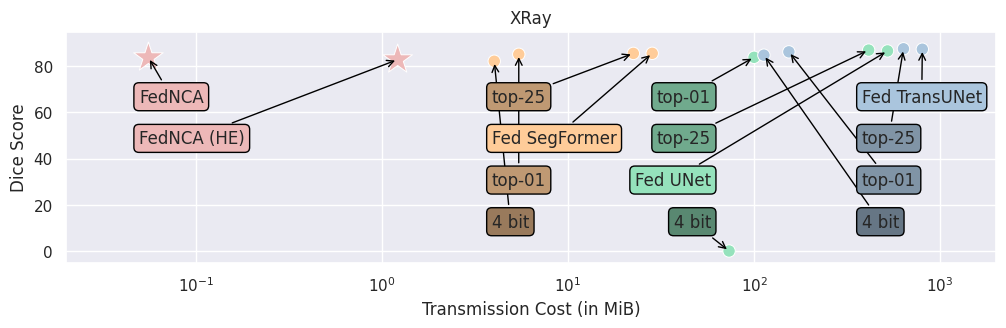

In [ ]:
sns.set_theme()
plt.figure(figsize=(12, 3))

color_dict = {
    "FedNCA": np.array((237/255, 184/255, 184/255)),
    "UNet": np.array((149/255, 226/255, 188/255)),
    "TransUNet": np.array((170/255, 197/255, 221/255)),
    "SegFormer":np.array((255/255, 204/255, 153/255))
}

color_dict["ViT"] = color_dict["SegFormer"]
#color_dict["CNN"] = color_dict["SegFormer"]
color_dict["DenseNet"] = color_dict["UNet"]
color_dict["ResNet18"] = color_dict["UNet"]

markers = {k : "o" for k in color_dict.keys()}
markers["FedNCA"] = "*"
sizes = {k: 80 for k in color_dict.keys()}
sizes["FedNCA"] = 500

ax = sns.scatterplot(data=results_for_plot, x="Cost", y="Dice", size="Arch", legend=False,
                hue="Arch", 
                #style="Meth"
                style="Arch",
                markers = markers,
                sizes = sizes,
                palette=color_dict
                )
def my_annotate(name, xytext, alttext=None, ha='left'):
    values = annotation_dict[name]
    col = color_dict[values["arch"]]
    brightness = 1.0
    if "top" in values["method"]:
        brightness = 0.75
    elif "bit" in values["method"]:
        brightness = 0.6
    col = np.clip(brightness * col, 0, 1)
    name = alttext if alttext else name
    return ax.annotate(name, values["pos"], textcoords="figure points", xytext=xytext, ha=ha, va='top',
        bbox=dict(boxstyle="round,pad=0.3", edgecolor="black", facecolor=col),
        arrowprops=dict(arrowstyle="->", color='black'))

if task == "Ultrasound":
    top = 160
    space = 30
    my_annotate("FedNCA", (70, top))
    my_annotate("FedNCA (HE)", (70, top-space))
    unet = 1.15 * 428
    my_annotate("Fed UNet", (unet, top-2*space), ha='right')
    my_annotate("UNet (4 bit)", (unet, top-3*space), "4 bit", ha='right')
    my_annotate("UNet (top-25)", (unet, top-1*space), "top-25", ha='right')
    my_annotate("UNet (top-01)", (unet, top-0*space), "top-01", ha='right')
    transunet = 1.2 * 500
    my_annotate("Fed TransUNet", (transunet, top-2*space))
    my_annotate("TransUNet (4 bit)", (transunet, top-3*space), "4 bit").zorder = 2.9
    my_annotate("TransUNet (top-25)", (transunet, top-1*space), "top-25")
    my_annotate("TransUNet (top-01)", (transunet, top-0*space), "top-01")
    segformer = 1.2 * 280
    my_annotate("Fed SegFormer", (segformer, top-2*space), ha='right')
    my_annotate("SegFormer (4 bit)", (segformer, top-3*space), "4 bit", ha='right')
    my_annotate("SegFormer (top-25)", (segformer, top-1*space), "top-25", ha='right')
    my_annotate("SegFormer (top-01)", (segformer, top-0*space), "top-01", ha='right')

    plt.xlim(0.02, 2000)
    ymin, ymax = plt.ylim()
    plt.ylim(ymin, ymax+4)
elif task == "XRay":
    top = 173
    space = 30
    my_annotate("FedNCA", (100, top))
    my_annotate("FedNCA (HE)", (100, top-space))

    unet = 1.13 * 453
    my_annotate("UNet (top-01)", (unet, top), "top-01", ha='right')
    my_annotate("UNet (top-25)", (unet, top-1*space), "top-25", ha='right').zorder = 2.9
    my_annotate("Fed UNet", (unet, top-2*space), ha='right').zorder = 2.8
    my_annotate("UNet (4 bit)", (unet, top-3*space), "4 bit", ha='right').zorder = 2.7
    transunet = 1.2 * 517
    my_annotate("Fed TransUNet", (transunet, top))
    my_annotate("TransUNet (top-25)", (transunet, top-space), "top-25").zorder = 2.9
    my_annotate("TransUNet (top-01)", (transunet, top-2*space), "top-01").zorder = 2.8
    my_annotate("TransUNet (4 bit)", (transunet, top-3*space), "4 bit").zorder = 2.7
    segformer = 1.2 * 295
    my_annotate("SegFormer (top-25)", (segformer, top), "top-25")
    my_annotate("Fed SegFormer", (segformer, top-space)).zorder = 2.9
    my_annotate("SegFormer (top-01)", (segformer, top-2*space), "top-01").zorder = 2.8
    my_annotate("SegFormer (4 bit)", (segformer, top-3*space), "4 bit").zorder = 2.7
    plt.ylim(-5, 95)
    plt.xlim(0.02, 2000)
elif task == "CRC":
    top = 190
    space = 30
    my_annotate("FedNCA", (150, top))
    my_annotate("FedNCA (HE)", (150, top-space))
    densenet = 1. * 340
    my_annotate("Fed DenseNet", (densenet, top-0*space), ha='left')
    my_annotate("DenseNet (4 bit)", (densenet, top-3*space), "4 bit", ha='left')
    my_annotate("DenseNet (top-25)", (densenet, top-1*space), "top-25", ha='left')
    my_annotate("DenseNet (top-01)", (densenet, top-2*space), "top-01", ha='left')
    vit = 1.45 * 487
    my_annotate("ViT (top-25)", (vit, top-2*space), "top-25", ha='right')
    my_annotate("Fed ViT", (vit, top-1*space), ha='right')
    my_annotate("ViT (4 bit)", (vit, top-4*space), "4 bit", ha='right')
    my_annotate("ViT (top-01)", (vit, top-3*space), "top-01", ha='right')
    plt.xlim(0.02, 2000)
    plt.ylim(5, 99)

plt.xscale('log')
plt.xlabel("Transmission Cost (in MiB)")
if task == "CRC":
    plt.ylabel("Accuracy")
else:
    plt.ylabel("Dice Score")
plt.title("Histopathology" if task == "CRC" else task)
plt.savefig(f"./results_{task}.pdf", bbox_inches='tight')